In [1]:
import numpy as np
import matplotlib.pyplot as plt
## USE PANDAS HERE!!
import pandas as pd

In [2]:
paths = [
    "./RL/logs/first_run_policy/run_20260313_025553_metrics.csv",
    "./RL/logs/first_run_policy/run_20260313_191058_metrics.csv",
    "./RL/logs/first_run_policy/run_20260314_140430_metrics.csv",
    "./RL/logs/first_run_policy/run_20260315_162817_metrics.csv",
    "./RL/logs/first_run_policy/run_20260316_184011_metrics.csv",
]

In [4]:
def fuse_raw_data(paths):
    n_files = len(paths)
    df = pd.read_csv(paths[0])
    for i in range(1, n_files):
        df = pd.concat([df, pd.read_csv(paths[i])], ignore_index=True)

    return df

In [11]:
raw_data.columns

Index(['update', 'wall_time_s', 't_dist_s', 't_collect_s', 't_gae_s',
       't_ppo_s', 'n_finished', 'n_won', 'win_rate', 'avg_ep_len',
       'avg_reward', 'p_loss', 'v_loss', 'entropy', 'vram_alloc_before_mb',
       'vram_reserved_before_mb', 'vram_alloc_after_mb',
       'vram_reserved_after_mb'],
      dtype='str')

In [12]:
all_data = fuse_raw_data(paths)

In [13]:
all_data

,update,wall_time_s,t_dist_s,t_collect_s,t_gae_s,t_ppo_s,n_finished,n_won,win_rate,avg_ep_len,avg_reward,p_loss,v_loss,entropy,vram_alloc_before_mb,vram_reserved_before_mb,vram_alloc_after_mb,vram_reserved_after_mb
0,0,207.505,0.303,101.228,0.0109,105.475,4,4,1.0000,4096.00,-133.5250,-0.000658,1.089829,2.344430,4.2,6.0,34.2,188.0
1,1,310.058,0.128,166.231,0.0123,143.111,4,4,1.0000,4096.00,-0.8750,0.000722,0.880297,2.845965,34.2,188.0,34.2,204.0
2,2,423.038,0.066,227.712,0.0117,194.481,2,2,1.0000,8192.00,-39.6000,-0.006327,0.861784,3.138917,34.2,204.0,34.2,204.0
3,3,501.784,0.057,278.268,0.0120,222.619,0,0,0.0000,16384.00,153.4000,-0.010105,0.465384,3.218770,34.2,204.0,34.2,228.0
4,4,580.000,0.061,315.247,0.0115,263.809,0,0,0.0000,16384.00,465.1000,0.003868,0.497937,3.450262,34.2,228.0,34.2,230.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,995.137,0.065,471.649,0.0109,522.222,0,0,0.0000,16384.00,2822.1001,-0.001417,0.165840,1.179869,33.8,242.0,33.8,256.0
496,496,958.551,0.034,480.377,0.0106,477.004,3,1,0.3333,5461.33,1026.9001,-0.008927,0.225029,1.183229,33.8,256.0,34.2,264.0
497,497,988.226,0.056,480.201,0.0105,506.774,1,1,1.0000,16384.00,3057.8000,-0.019794,0.296073,1.209164,34.2,264.0,34.2,258.0
498,498,961.522,0.049,479.639,0.0097,480.607,0,0,0.0000,16384.00,3089.8000,0.004135,0.213376,1.339201,34.2,258.0,33.8,254.0


Text(0, 0.5, 'time in seconds')

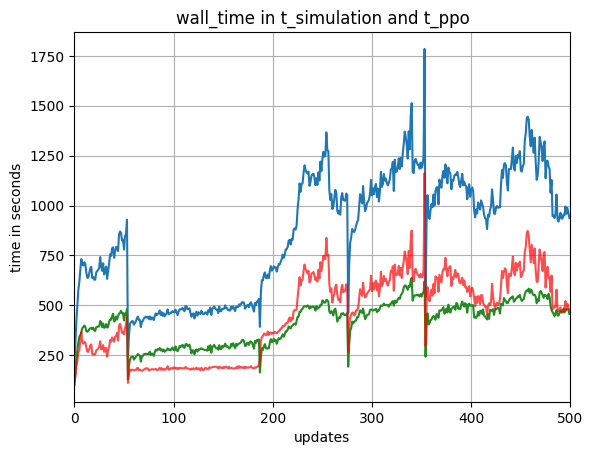

In [39]:
plt.plot(all_data["wall_time_s"])
plt.plot(all_data["t_collect_s"], color="forestgreen")
plt.plot(all_data["t_ppo_s"], color="red", alpha=0.7)
plt.grid(True)
plt.xlim(0,500)
plt.title("wall_time in t_simulation and t_ppo")
plt.xlabel("updates")
plt.ylabel("time in seconds")

Text(0, 0.5, 'units')

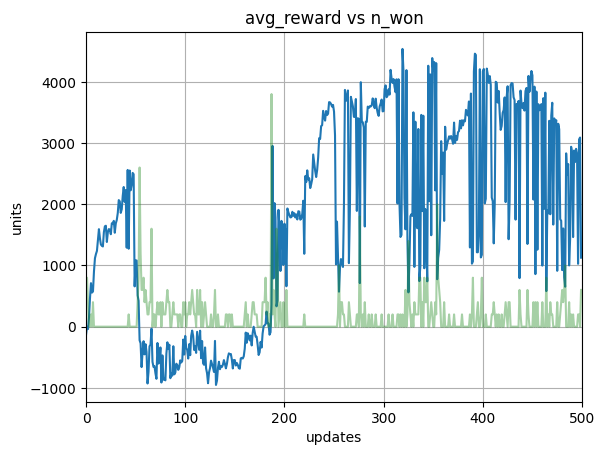

In [40]:
plt.plot(all_data["avg_reward"])
plt.plot(all_data["n_won"]*200, color="forestgreen", alpha=0.4)
plt.grid(True)
plt.xlim(0,500)
plt.title("avg_reward vs n_won")
plt.xlabel("updates")
plt.ylabel("units")

Text(0, 0.5, 'loss units')

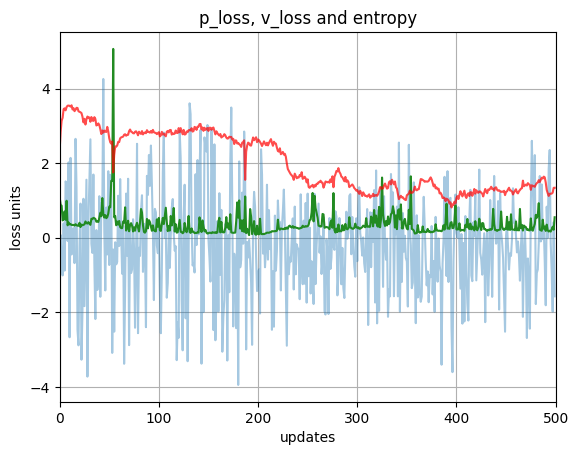

In [41]:
plt.plot(all_data["p_loss"]*100, alpha=0.4)
plt.plot(all_data["v_loss"], color="forestgreen")
plt.plot(all_data["entropy"], color="red", alpha=0.7)
plt.grid(True)
plt.xlim(0,500)
plt.title("p_loss, v_loss and entropy")
plt.xlabel("updates")
plt.ylabel("loss units")

## Continue training with reward curriculum

In [2]:
paths_RC = [
    "./RL/logs/run_win_20260318_204308_metrics.csv",
    "./RL/logs/run_win_20260318_231026_metrics.csv",
    "./RL/logs/run_win_20260326_153245_metrics.csv",
    "./RL/logs/run_win_20260331_120722_metrics.csv",
]

In [5]:
RC_all_data = fuse_raw_data(paths_RC)
RC_all_data

,update,n_simul_rounds,wall_time_s,t_dist_s,t_collect_s,t_gae_s,t_ppo_s,n_finished,n_won,win_rate,avg_ep_len,avg_reward,p_loss,v_loss,entropy,vram_alloc_before_mb,vram_reserved_before_mb,vram_alloc_after_mb,vram_reserved_after_mb
0,0,1,366.554,0.285,113.214,0.0125,252.328,20,20,1.0,819.20,20.0,-0.002238,1.922642,0.654208,4.2,10.0,34.2,124.0
1,1,1,420.115,0.133,155.909,0.0115,262.873,16,16,1.0,1024.00,20.0,0.001039,0.557758,0.924639,34.2,124.0,34.2,160.0
2,2,1,311.403,0.067,159.016,0.0109,151.086,12,12,1.0,1365.33,20.0,0.002416,0.386666,0.883724,34.2,160.0,34.2,158.0
3,3,1,333.589,0.079,158.363,0.0126,173.940,12,12,1.0,1365.33,20.0,0.002342,0.445012,0.862948,34.2,158.0,34.2,158.0
4,4,1,255.666,0.155,163.504,0.0113,90.946,7,7,1.0,2340.57,20.0,0.002357,0.448944,1.230104,34.2,158.0,34.2,170.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,1,1116.110,0.101,667.304,0.0224,439.743,5,5,1.0,6553.60,20.0,0.009347,0.459455,2.503227,34.2,226.0,34.2,230.0
496,496,1,900.145,0.122,630.127,0.0234,261.240,8,8,1.0,4096.00,20.0,0.000421,0.777874,1.900563,34.2,230.0,34.2,218.0
497,497,2,2141.926,0.301,1367.116,0.0225,756.615,5,5,1.0,6553.60,20.0,-0.003852,0.363054,2.780390,34.2,218.0,34.2,240.0
498,498,1,1087.187,0.100,745.504,0.0233,332.144,7,7,1.0,4681.14,20.0,0.007830,0.410307,1.845641,34.2,240.0,34.2,206.0


Text(0, 0.5, 'time in seconds')

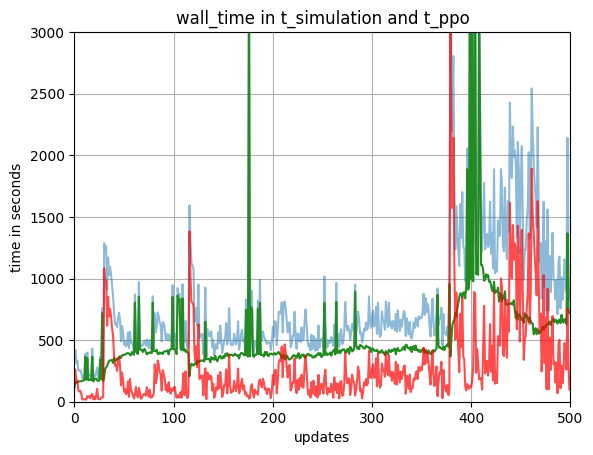

In [13]:
plt.plot(RC_all_data["wall_time_s"], alpha=.5)
plt.plot(RC_all_data["t_collect_s"], color="forestgreen", alpha=1)
plt.plot(RC_all_data["t_ppo_s"], color="red", alpha=0.7)
plt.grid(True)
plt.xlim(0,500)
plt.ylim(0, 3000)
plt.title("wall_time in t_simulation and t_ppo")
plt.xlabel("updates")
plt.ylabel("time in seconds")

Text(0, 0.5, 'n_won scaled by 4')

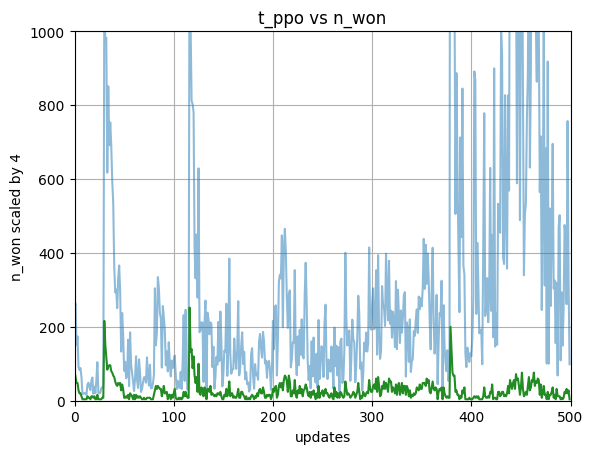

In [14]:
plt.plot(RC_all_data["t_ppo_s"], alpha=0.5)
plt.plot(RC_all_data["n_won"]*4, color="forestgreen", alpha=1)
plt.grid(True)
plt.xlim(0,500)
plt.ylim(0,1000)
plt.title("t_ppo vs n_won")
plt.xlabel("updates")
plt.ylabel("n_won scaled by 4")

Text(0, 0.5, 'loss units')

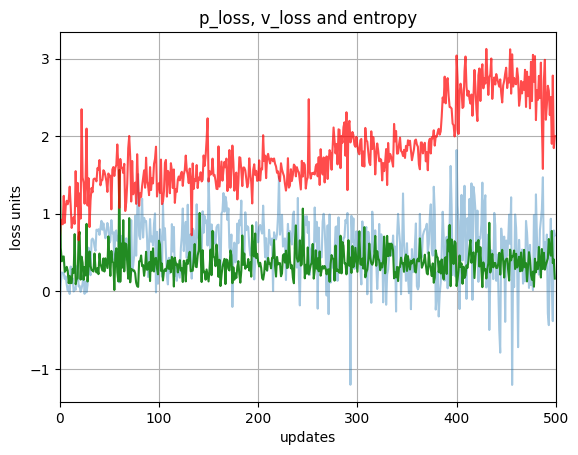

In [12]:
plt.plot(RC_all_data["p_loss"]*100, alpha=0.4)
plt.plot(RC_all_data["v_loss"], color="forestgreen")
plt.plot(RC_all_data["entropy"], color="red", alpha=0.7)
plt.grid(True)
plt.xlim(0,500)
plt.title("p_loss, v_loss and entropy")
plt.xlabel("updates")
plt.ylabel("loss units")